In [ ]:
### THIS NOTEBOOK LOADS AND PLOTS THE RESULTS FOR ALL AGENTS ###

In [ ]:
### IMPORTS ###
import gymnasium as gym
import ale_py

import random
import numpy as np
import matplotlib.pyplot as plt


import torch


In [45]:
labels = ['DSQN','DDQN','DQN','DSN','Semi-Gradient SARSA','TD(0) Linear', 'TD(0) NN']
filenames = ['DSQN','DDQN','DQN','DSN','semigradientsarsa','TD0Linear', 'TD0neural']
filetype = ['.pth'] * 5
filetype.append('.npy')
filetype.append('.npy')

episodelength = {'': [1500,-400],'mod': [2000,-500]}

In [42]:
def randomagent(gameversion):

    if gameversion == '':
        env_random = gym.make("LunarLander-v3")
    elif gameversion == 'mod':
        env_random = gym.make("LunarLander-v3",enable_wind = True,wind_power = 15.0,gravity = -10.0,turbulence_power = 1.5)
    reward_episode = []
    for i in range (0,100):
      reward_counter = 0
      done = False
      observation, info = env_random.reset()

      while done == False:

         action = env_random.action_space.sample()

   
         observation, reward, terminated, truncated, info = env_random.step(action)
         done = terminated or truncated

         reward_counter += reward 

      reward_episode.append(reward_counter)

      env_random.close()

    return np.mean(reward_episode)

In [25]:
b = torch.load('agents_results' + 'mod' + '/' + 'mod'  +'params_' + labels[0] + '.pth', weights_only=False)


In [47]:
def plotting(gameversion):
    plt.figure(figsize=(10, 8))
    for i in range(0,5):
        result = torch.load('agents_results' + gameversion + '/' + gameversion  +'params_' + filenames[i] + '.pth', weights_only=False)
        plt.plot(np.linspace(0,episodelength[gameversion][0]-1,episodelength[gameversion][0]),result['moving_average'],label = labels[i])

    for i in range(5,7):

        result = np.load('agents_results' + gameversion + '/' + gameversion  +'params_' + filenames[i] + '.npy')
        plt.plot(np.linspace(0,episodelength[gameversion][0]-1,episodelength[gameversion][0]),result,label = labels[i])

    plt.axhline(y=200, color='black', linestyle='--', linewidth=1, label = 'solution')
    plt.axhline(y = randomagent(gameversion), linestyle='--', linewidth=1, label = 'random')

    plt.xlabel('Episode')
    plt.ylabel('Average Reward')
    plt.ylim(episodelength[gameversion][1], 400)
    

    plt.legend(frameon=False, loc = 'upper left')
    plt.show()

    return

 


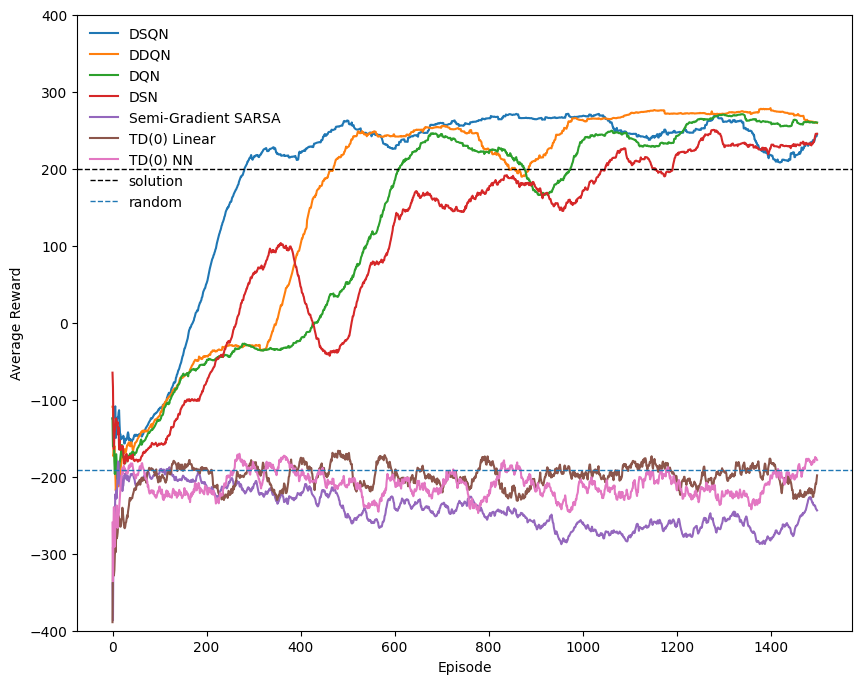

In [50]:
plotting('')

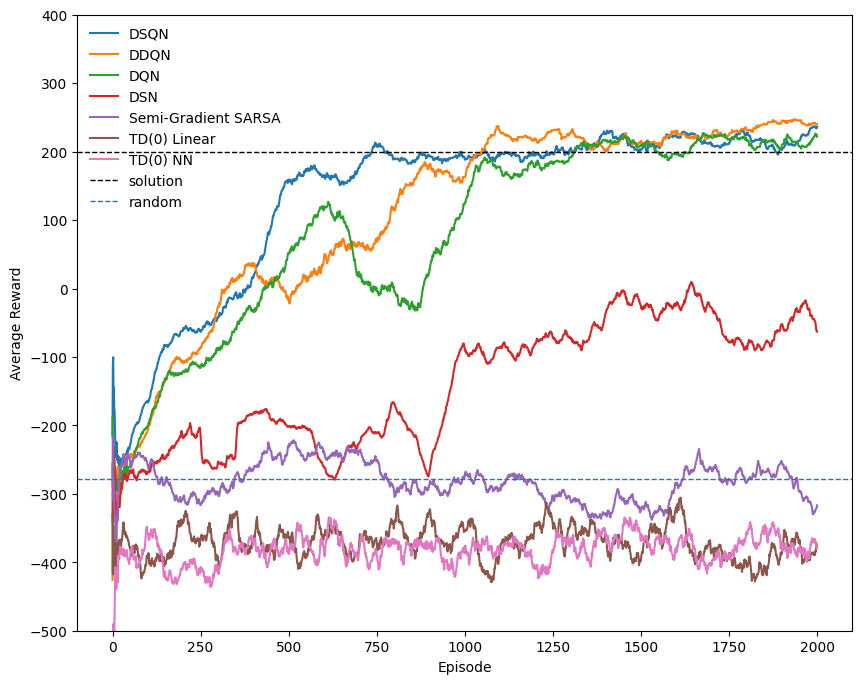

In [49]:
plotting('mod')